
# 02 - Exploratory Data Analysis (EDA)

## Objetivo

Realizar uma análise exploratória da base final `customer_offer_final`, avaliando:

- distribuição das variáveis;
- comportamento das ofertas;
- padrões de conversão;
- características históricas dos clientes;
- possíveis inconsistências temporais dos eventos.


In [1]:
import os

os.environ["JAVA_HOME"] = "/opt/homebrew/opt/openjdk@17"
os.environ["PATH"] = os.environ["JAVA_HOME"] + "/bin:" + os.environ["PATH"]

In [2]:

from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from scipy.stats import pointbiserialr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


In [3]:
spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("offer_personalization_data_processing")
    .config("spark.driver.bindAddress", "127.0.0.1")
    .config("spark.driver.host", "127.0.0.1")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")
spark.version

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/05/19 02:47:02 WARN Utils: Your hostname, jorel.local, resolves to a loopback address: 127.0.0.1; using 192.168.0.7 instead (on interface en0)
26/05/19 02:47:02 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/19 02:47:03 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/05/19 02:47:03 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


'4.0.2'


## Leitura da base final


In [4]:

customer_offer_final = spark.read.parquet(
    "../data/processed/customer_offer_transactions.parquet"
)

customer_offer_final.printSchema()


root
 |-- account_id: string (nullable = true)
 |-- offer_id: string (nullable = true)
 |-- offer_received_time: double (nullable = true)
 |-- offer_viewed_time: double (nullable = true)
 |-- offer_completed_time: double (nullable = true)
 |-- offer_received: integer (nullable = true)
 |-- offer_viewed: integer (nullable = true)
 |-- offer_completed: integer (nullable = true)
 |-- time_to_view: double (nullable = true)
 |-- time_to_complete: double (nullable = true)
 |-- previous_offer_time_to_complete: double (nullable = true)
 |-- transactions_during_offer: long (nullable = true)
 |-- amount_during_offer: double (nullable = true)
 |-- reward: double (nullable = true)
 |-- discount_value: double (nullable = true)
 |-- min_value: double (nullable = true)
 |-- duration: double (nullable = true)
 |-- offer_type: string (nullable = true)
 |-- email: integer (nullable = true)
 |-- mobile: integer (nullable = true)
 |-- social: integer (nullable = true)
 |-- web: integer (nullable = true)
 

In [5]:
customer_offer_final.show(5, truncate=False)


+--------------------------------+--------------------------------+-------------------+-----------------+--------------------+--------------+------------+---------------+------------+----------------+-------------------------------+-------------------------+-------------------+------+--------------+---------+--------+----------+-----+------+------+---+---+------+-----------------+-------------+----------------+-------------------------+-------------------+----------------------+-----------------------+----------------------------+--------------------------------+-----------------------+----------------------+
|account_id                      |offer_id                        |offer_received_time|offer_viewed_time|offer_completed_time|offer_received|offer_viewed|offer_completed|time_to_view|time_to_complete|previous_offer_time_to_complete|transactions_during_offer|amount_during_offer|reward|discount_value|min_value|duration|offer_type|email|mobile|social|web|age|gender|credit_card_limit|


## Volume da base


In [6]:
print(f"Total de linhas: {customer_offer_final.count():,}")
print(f"Total de clientes: {customer_offer_final.select('account_id').distinct().count():,}")
print(f"Total de ofertas únicas: {customer_offer_final.select('offer_id').distinct().count():,}")


Total de linhas: 76,277
Total de clientes: 16,994
Total de ofertas únicas: 10



## Conversão geral


In [7]:
conversion_rate = (
    customer_offer_final
    .groupBy("offer_completed")
    .count()
    .toPandas()
)

conversion_rate["pct"] = (
   conversion_rate["count"] / conversion_rate["count"].sum()*100
)

conversion_rate


,offer_completed,count,pct
0,1,33631,44.090617
1,0,42646,55.909383


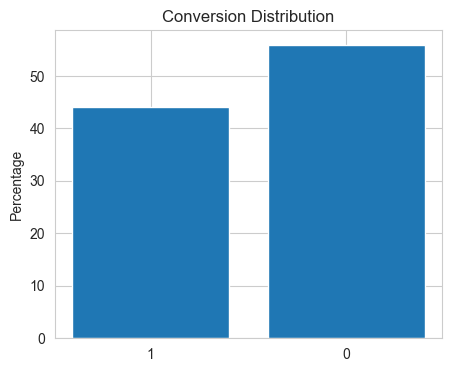

In [8]:
plt.figure(figsize=(5,4))

plt.bar(
    conversion_rate["offer_completed"].astype(str),
    conversion_rate["pct"]
)

plt.title("Conversion Distribution")
plt.ylabel("Percentage")

plt.show()



## Conversão por tipo de oferta


In [9]:

offer_conversion = (
    customer_offer_final
    .groupBy("offer_type")
    .agg(
        (avg("offer_completed")*100).alias("conversion_rate")
    )
    .orderBy(desc("conversion_rate"))
    .toPandas()
)

offer_conversion


,offer_type,conversion_rate
0,discount,58.808892
1,bogo,51.375455
2,informational,0.000000


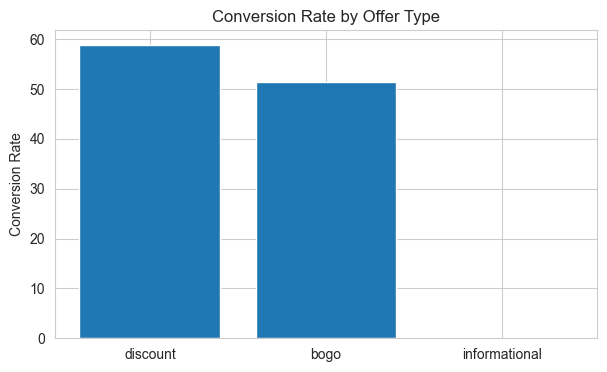

In [10]:
plt.figure(figsize=(7,4))

plt.bar(
    offer_conversion["offer_type"],
    offer_conversion["conversion_rate"]
)

plt.title("Conversion Rate by Offer Type")
plt.ylabel("Conversion Rate")

plt.show()



## Distribuição de variáveis numéricas


In [11]:

numeric_cols = [
    "discount_value",
    "min_value",
    "duration",
    "transactions_before_offer",
    "amount_before_offer",
    "avg_ticket_before_offer",
    "completion_rate_before",
    "credit_card_limit",
    "account_age_days"
]

pdf = (
    customer_offer_final
    .select(numeric_cols)
    .toPandas()
)


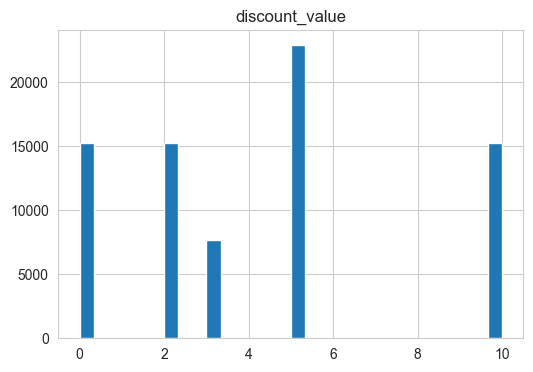

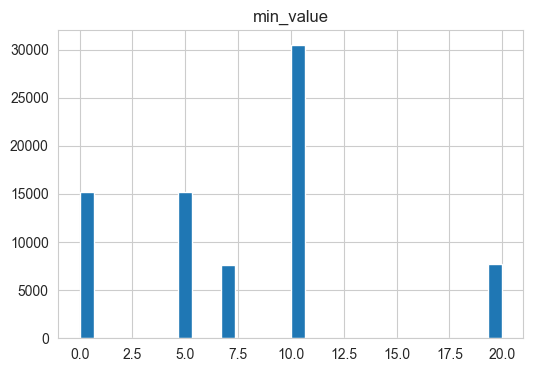

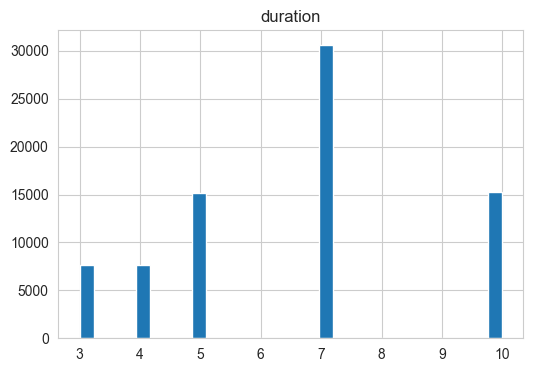

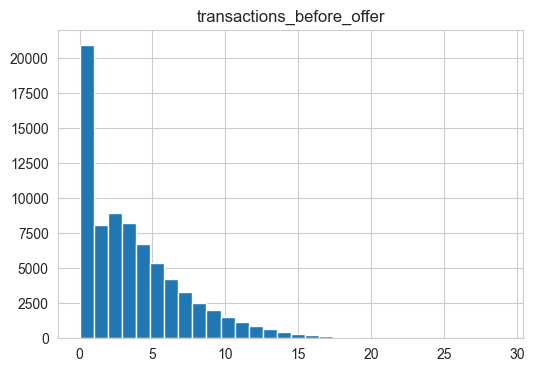

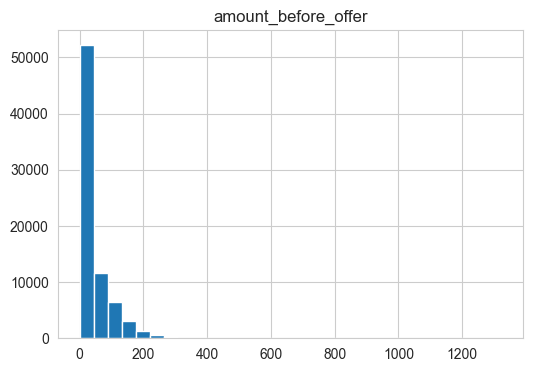

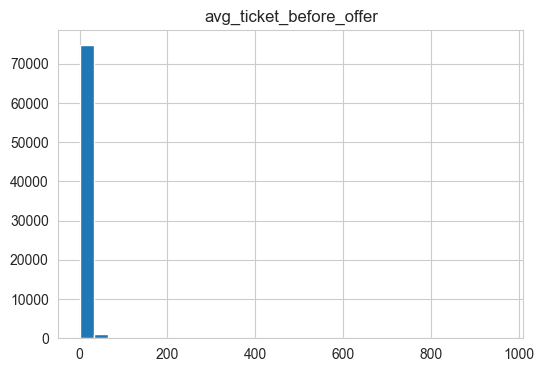

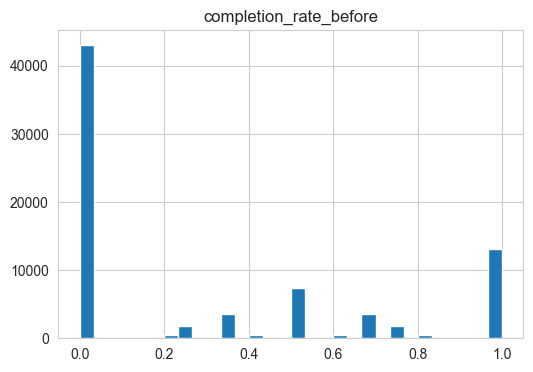

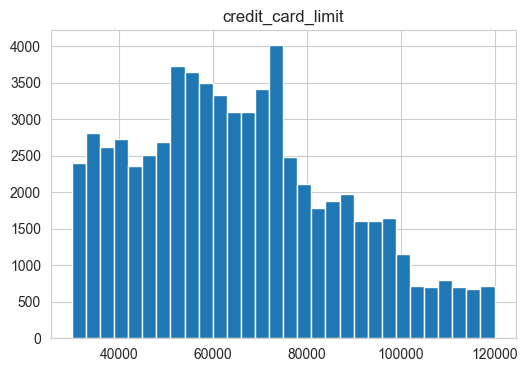

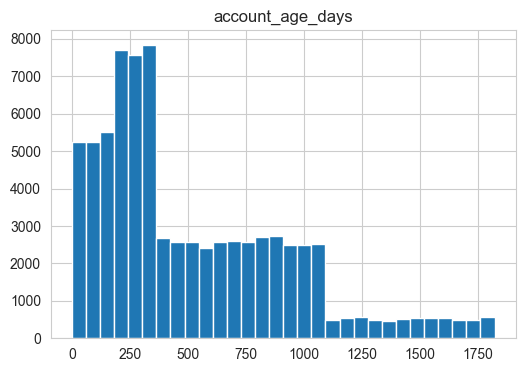

In [12]:

for col_name in numeric_cols:

    plt.figure(figsize=(6,4))

    plt.hist(
        pdf[col_name].dropna(),
        bins=30
    )

    plt.title(col_name)

    plt.show()



## Comparação entre convertidos e não convertidos


In [13]:
customer_offer_final.columns

['account_id',
 'offer_id',
 'offer_received_time',
 'offer_viewed_time',
 'offer_completed_time',
 'offer_received',
 'offer_viewed',
 'offer_completed',
 'time_to_view',
 'time_to_complete',
 'previous_offer_time_to_complete',
 'transactions_during_offer',
 'amount_during_offer',
 'reward',
 'discount_value',
 'min_value',
 'duration',
 'offer_type',
 'email',
 'mobile',
 'social',
 'web',
 'age',
 'gender',
 'credit_card_limit',
 'registered_on',
 'account_age_days',
 'transactions_before_offer',
 'amount_before_offer',
 'offers_received_before',
 'offers_completed_before',
 'bogo_offers_completed_before',
 'discount_offers_completed_before',
 'avg_ticket_before_offer',
 'completion_rate_before']

In [14]:
customer_offer_final.show(5, truncate=False)

+--------------------------------+--------------------------------+-------------------+-----------------+--------------------+--------------+------------+---------------+------------+----------------+-------------------------------+-------------------------+-------------------+------+--------------+---------+--------+----------+-----+------+------+---+---+------+-----------------+-------------+----------------+-------------------------+-------------------+----------------------+-----------------------+----------------------------+--------------------------------+-----------------------+----------------------+
|account_id                      |offer_id                        |offer_received_time|offer_viewed_time|offer_completed_time|offer_received|offer_viewed|offer_completed|time_to_view|time_to_complete|previous_offer_time_to_complete|transactions_during_offer|amount_during_offer|reward|discount_value|min_value|duration|offer_type|email|mobile|social|web|age|gender|credit_card_limit|

In [15]:
comparison = (
    customer_offer_final
    .groupBy("offer_completed")
    .agg(
        avg("transactions_before_offer").alias("avg_transactions_before_offer"),
        avg("amount_before_offer").alias("avg_amount_before_offer"),
        avg("avg_ticket_before_offer").alias("avg_ticket_before_offer"),
        sum("offers_completed_before").alias("total_offers_completed_before"),
        sum("bogo_offers_completed_before").alias("total_bogo_completed_before"),
        sum("discount_offers_completed_before").alias("total_discount_completed_before"),
        (avg("completion_rate_before") * 100).alias("avg_completion_rate_before")
    )
    .withColumn(
        "pct_bogo_completed_before",
        when(
            col("total_offers_completed_before") > 0,
            (col("total_bogo_completed_before") / col("total_offers_completed_before")) * 100
        ).otherwise(0)
    )
    .withColumn(
        "pct_discount_completed_before",
        when(
            col("total_offers_completed_before") > 0,
            (col("total_discount_completed_before") / col("total_offers_completed_before")) * 100
        ).otherwise(0)
    )
    .toPandas()
)

comparison

,offer_completed,avg_transactions_before_offer,avg_amount_before_offer,avg_ticket_before_offer,total_offers_completed_before,total_bogo_completed_before,total_discount_completed_before,avg_completion_rate_before,pct_bogo_completed_before,pct_discount_completed_before
0,1,3.911391,63.097710,13.606189,34445,16664,17781,42.330588,48.378575,51.621425
1,0,3.098016,28.611103,6.732375,21883,10065,11818,20.793236,45.994608,54.005392


Clientes que converteram ofertas apresentaram, em média:

- maior volume histórico de transações;
- maior gasto acumulado antes da oferta;
- ticket médio mais elevado;
- maior taxa histórica de conversão.

| Métrica                     | Não converteu | Converteu |
| --------------------------- | ------------: | --------: |
| Transações anteriores       |          3.10 |      3.91 |
| Valor gasto antes da oferta |         28.61 |     63.10 |
| Ticket médio histórico      |          6.73 |     13.61 |
| Taxa histórica de conversão |          0.21 |      0.42 |



## Correlação entre variáveis numéricas


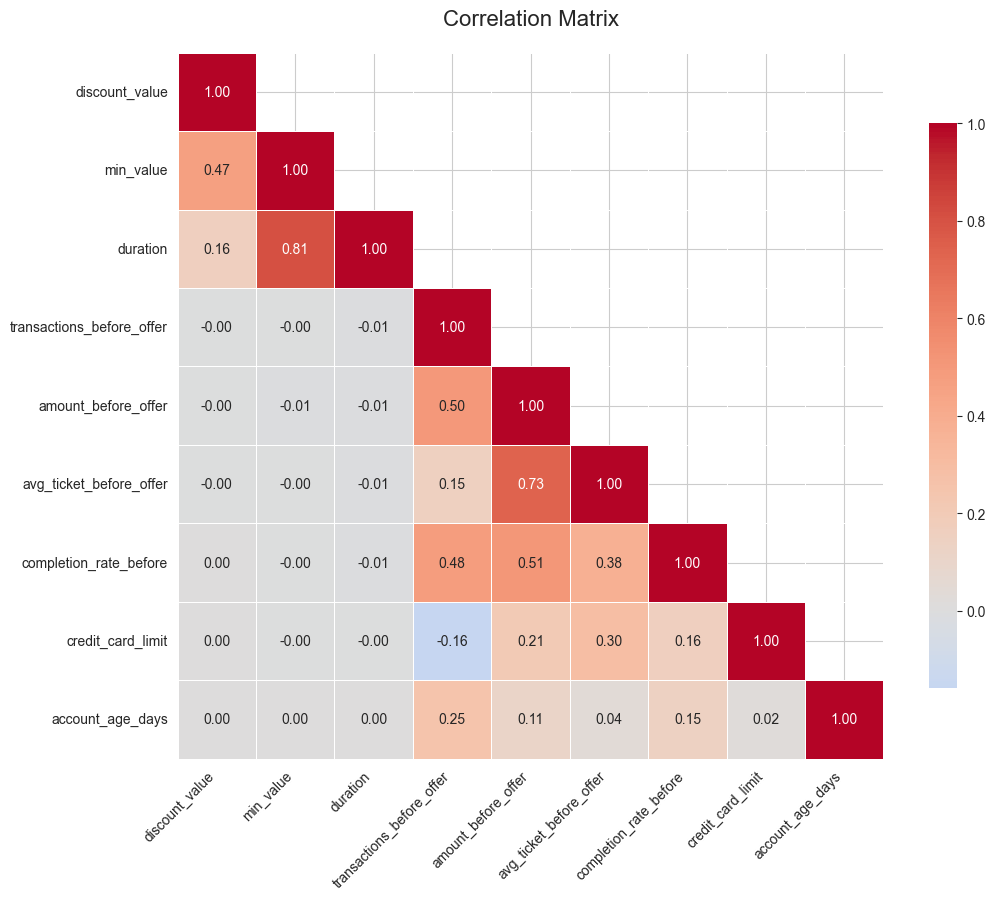

In [16]:
corr = pdf.corr(numeric_only=True)

plt.figure(figsize=(11, 9))

mask = np.triu(
    np.ones_like(corr, dtype=bool),
    k=1
)

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title(
    "Correlation Matrix",
    fontsize=16,
    pad=20
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

**A análise de correlação mostra que:**

- variáveis promocionais apresentam correlação moderada entre si, especialmente entre duration e min_value;
- variáveis históricas de comportamento possuem associação positiva entre volume transacional e taxa histórica de conversão;
- não foram observados níveis severos de multicolinearidade entre a maioria das variáveis;
- características promocionais e comportamentais apresentaram baixa correlação entre grupos, indicando complementaridade de informação para o modelo preditivo.

Os resultados sugerem que a base final possui boa diversidade de sinais explicativos para modelagem de conversão de ofertas.

In [17]:
numeric_cols = [
    "discount_value",
    "min_value",
    "duration",
    "transactions_before_offer",
    "amount_before_offer",
    "offers_received_before",
    "offers_completed_before",
    "bogo_offers_completed_before",
    "discount_offers_completed_before",
    "avg_ticket_before_offer",
    "completion_rate_before",
    "credit_card_limit",
    "account_age_days",
    "previous_offer_time_to_complete"
]

pdf_corr = (
    customer_offer_final
    .select(
        numeric_cols + ["offer_completed"]
    )
    .toPandas()
).dropna()

In [18]:
corr_results = []

for feature in numeric_cols:

    corr, pvalue = pointbiserialr(
        pdf_corr["offer_completed"],
        pdf_corr[feature]
    )

    corr_results.append({
        "feature": feature,
        "correlation": corr,
        "pvalue": pvalue
    })

corr_df = (
    pd.DataFrame(corr_results)
    .sort_values(
        "correlation",
        ascending=False
    )
)

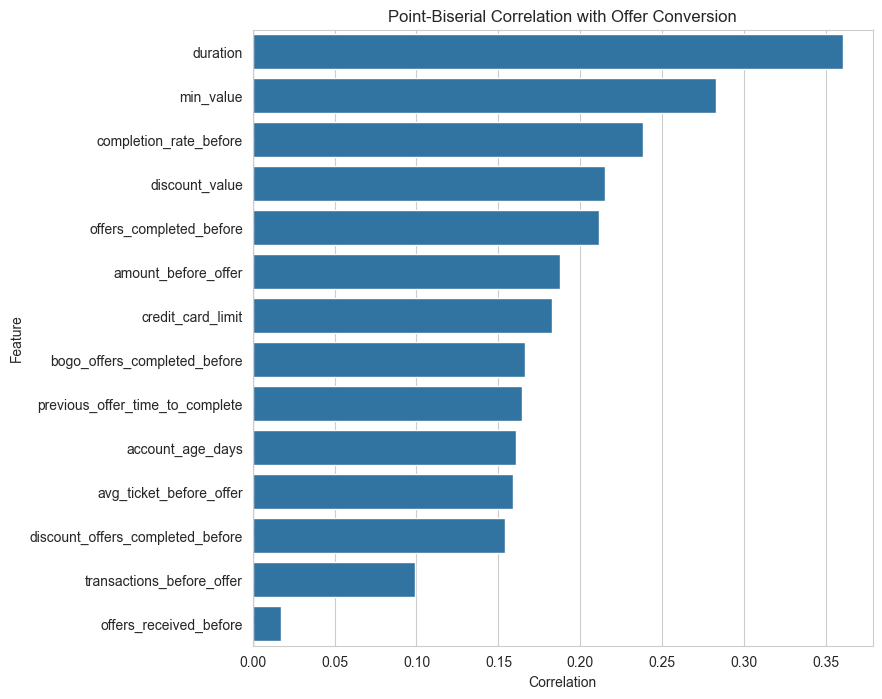

In [19]:
plt.figure(figsize=(8,8))

sns.barplot(
    data=corr_df,
    y="feature",
    x="correlation"
)

plt.axvline(0, color="black", linestyle="--")

plt.title(
    "Point-Biserial Correlation with Offer Conversion"
)

plt.xlabel("Correlation")
plt.ylabel("Feature")

plt.show()

**Correlação entre variáveis numéricas e conversão**

Foi utilizada a correlação point-biserial, apropriada para avaliar a relação entre variáveis numéricas e uma variável resposta binária (offer_completed).

Os principais resultados indicam que:

- clientes com maior histórico de conversão tendem a converter novamente;
- ofertas com maior duração apresentam maior associação positiva com conversão;
- variáveis históricas comportamentais apresentaram maior poder explicativo do que variáveis cadastrais;
- apenas aumentar o volume de ofertas enviadas não parece aumentar significativamente a conversão.

Esses resultados reforçam a importância de estratégias de personalização baseadas em comportamento histórico do cliente.


## Jornada de um cliente

Exemplo de jornada temporal para um cliente específico.


In [20]:
sample_account = "78afa995795e4d85b5d9ceeca43f5fef"

journey = (
    customer_offer_final
    .filter(col("account_id") == sample_account)
    .orderBy("offer_received_time")
    .toPandas()
)

journey[[
    "offer_id",
    "offer_type",
    "offer_received_time",
    "offer_viewed_time",
    "offer_completed_time",
    "offer_completed"
]]


,offer_id,offer_type,offer_received_time,offer_viewed_time,offer_completed_time,offer_completed
0,9b98b8c7a33c4b65b9aebfe6a799e6d9,bogo,0.0,0.25,5.50,1
1,5a8bc65990b245e5a138643cd4eb9837,informational,7.0,9.00,NaN,0
2,ae264e3637204a6fb9bb56bc8210ddfd,bogo,17.0,17.00,21.25,1
3,f19421c1d4aa40978ebb69ca19b0e20d,bogo,21.0,24.25,21.25,1


## Análise de distribuição de ofertas

In [21]:
customer_agg = (
    customer_offer_final
    .groupBy("account_id")
    .agg(
        count("*").alias("n_offers"),
        avg("offer_completed").alias("conversion_rate")
    )
    .toPandas()
)

In [22]:
offers_analysis = (
    customer_agg
    .groupby("n_offers")
    .agg(
        avg_conversion_rate=("conversion_rate", "mean"),
        n_customers=("conversion_rate", "count")
    )
    .reset_index()
)

offers_analysis

,n_offers,avg_conversion_rate,n_customers
0,1,0.465753,73
1,2,0.439344,610
2,3,0.435556,2325
3,4,0.436999,4988
4,5,0.447210,5931
5,6,0.437018,3067


A análise da distribuição de ofertas por cliente mostrou que o dataset possui baixa concentração de campanhas em clientes específicos.

A maior parte dos clientes recebeu entre 3 e 6 ofertas, sem presença relevante de usuários extremamente super-representados.

Além disso, a taxa média de conversão permaneceu relativamente estável independentemente da quantidade de ofertas recebidas, sugerindo baixa influência estrutural do volume de campanhas sobre o comportamento observado.

Dessa forma, não foi identificada necessidade de aplicação de ponderação amostral por cliente na modelagem final.


## Auditoria temporal

Durante a análise exploratória foram identificados casos em que:

```text
offer_completed_time < offer_viewed_time
```

Isso indica possíveis inconsistências de tracking ou atrasos de logging.

Por esse motivo, variáveis diretamente relacionadas ao evento de visualização não foram utilizadas como features principais na modelagem.


In [23]:
invalid_tracking = (
    customer_offer_final
    .filter(
        col("offer_completed_time") < col("offer_viewed_time")
    )
)

invalid_count = invalid_tracking.count()

total_completed = (
    customer_offer_final
    .filter(col("offer_completed") == 1)
    .count()
)

pct_invalid = 100 * invalid_count / total_completed

print(f"Inconsistências temporais: {invalid_count}")
print(f"Percentual: {pct_invalid:.2f}%")


Inconsistências temporais: 4220
Percentual: 12.55%



## Conclusões

Principais observações:

- ofertas do tipo Discount apresentaram maior taxa de conversão;
- clientes com maior histórico de engajamento tendem a converter mais;
- variáveis históricas pré-oferta apresentaram forte capacidade explicativa;
- foram identificadas inconsistências temporais nos eventos de visualização;
- a base final foi construída respeitando a temporalidade das informações.
